In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers   # type: ignore
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report

2026-04-30 11:35:50.971439: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777548951.339510      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777548951.448286      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777548952.362498      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777548952.362599      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777548952.362602      23 computation_placer.cc:177] computation placer alr

In [2]:
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1e0',
    'xtick.color':      '#7a82a0',
    'ytick.color':      '#7a82a0',
    'text.color':       '#c9d1e0',
    'grid.color':       '#2e3250',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
})
ACCENT  = '#4f8ef7'
ACCENT2 = '#f7614f'
ACCENT3 = '#4fcf8e'

In [3]:
COLS = ['unit','cycle','os1','os2','os3'] + [f's{i}' for i in range(1, 22)]
 
def load_data(path):
    return pd.read_csv(path, sep=r'\s+', header=None,
                       usecols=range(26), names=COLS, engine='python')
 
BASE = '/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/'
train = load_data(BASE + 'train_FD001.txt')
test  = load_data(BASE + 'test_FD001.txt')
rul   = pd.read_csv(BASE + 'RUL_FD001.txt', header=None, names=['rul'])
 
print(f"Train: {train.shape}  |  Test: {test.shape}  |  RUL entries: {len(rul)}")
print(f"Train engines: {train['unit'].nunique()}  |  Test engines: {test['unit'].nunique()}")

Train: (20631, 26)  |  Test: (13096, 26)  |  RUL entries: 100
Train engines: 100  |  Test engines: 100


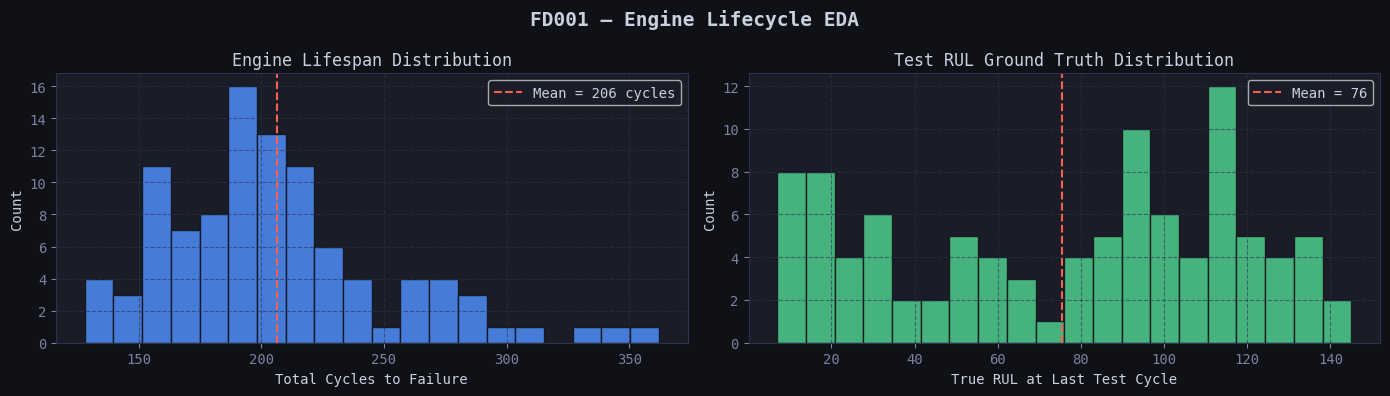

In [4]:
# ── 2a. Engine lifecycle distribution ─────────────────────────────────────────
engine_lives = train.groupby('unit')['cycle'].max()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('FD001 — Engine Lifecycle EDA', fontsize=14, fontweight='bold', color='#c9d1e0')
 
axes[0].hist(engine_lives, bins=20, color=ACCENT, alpha=0.85, edgecolor='#0f1117')
axes[0].axvline(engine_lives.mean(), color=ACCENT2, linestyle='--', lw=1.5,
                label=f'Mean = {engine_lives.mean():.0f} cycles')
axes[0].set_title('Engine Lifespan Distribution')
axes[0].set_xlabel('Total Cycles to Failure')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True)
 
axes[1].hist(rul['rul'], bins=20, color=ACCENT3, alpha=0.85, edgecolor='#0f1117')
axes[1].axvline(rul['rul'].mean(), color=ACCENT2, linestyle='--', lw=1.5,
                label=f'Mean = {rul["rul"].mean():.0f}')
axes[1].set_title('Test RUL Ground Truth Distribution')
axes[1].set_xlabel('True RUL at Last Test Cycle')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True)
 
plt.tight_layout()
plt.savefig('eda_lifecycle.png', dpi=150, bbox_inches='tight')
plt.show()

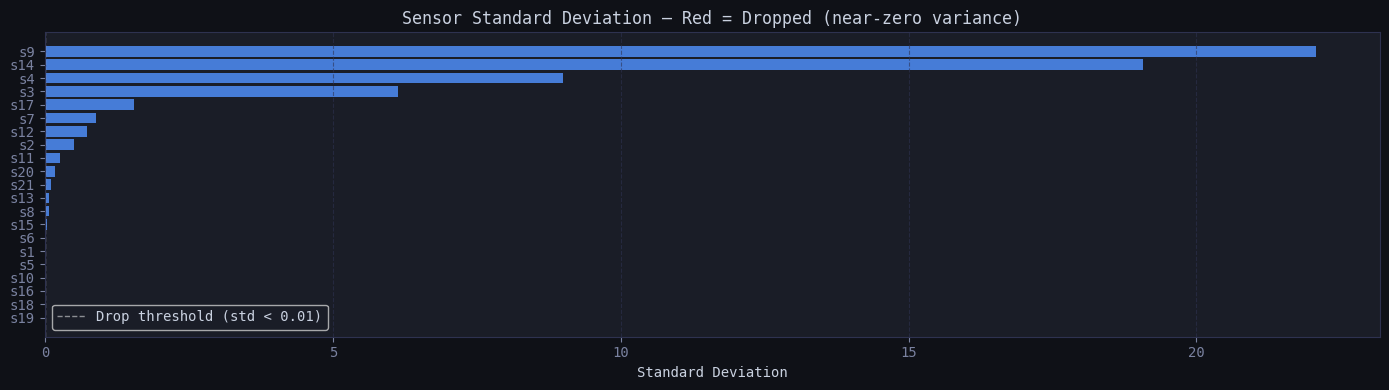

In [5]:
# ── 2b. Sensor variance — identify useless sensors ────────────────────────────
sensor_cols = [f's{i}' for i in range(1, 22)]
sensor_std  = train[sensor_cols].std().sort_values()
 
fig, ax = plt.subplots(figsize=(14, 4))
colors = [ACCENT2 if v < 0.01 else ACCENT for v in sensor_std.values]
ax.barh(sensor_std.index, sensor_std.values, color=colors, alpha=0.85)
ax.axvline(0.01, color='white', linestyle='--', lw=1, alpha=0.5, label='Drop threshold (std < 0.01)')
ax.set_title('Sensor Standard Deviation — Red = Dropped (near-zero variance)')
ax.set_xlabel('Standard Deviation')
ax.legend()
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('eda_sensor_variance.png', dpi=150, bbox_inches='tight')
plt.show()

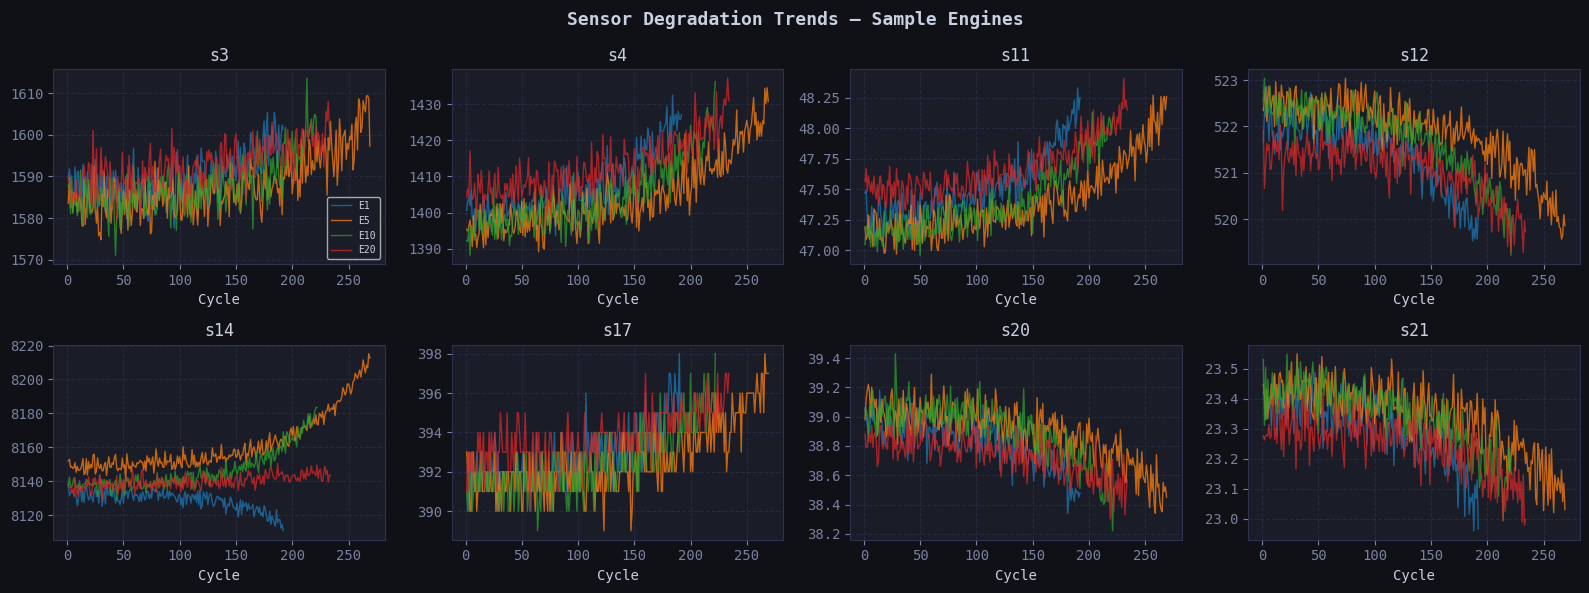

In [6]:
# ── 2c. Degradation signal — sample engines ───────────────────────────────────
KEEP_SENSORS = ['s2','s3','s4','s7','s9','s11','s12','s14','s17','s20','s21']
sample_units = [1, 5, 10, 20]
 
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Sensor Degradation Trends — Sample Engines', fontsize=13,
             fontweight='bold', color='#c9d1e0')
 
sensors_to_plot = ['s3', 's4', 's11', 's12', 's14', 's17', 's20', 's21']
for ax, sensor in zip(axes.flat, sensors_to_plot):
    for uid in sample_units:
        eng = train[train['unit'] == uid].sort_values('cycle')
        ax.plot(eng['cycle'], eng[sensor], lw=1, alpha=0.75, label=f'E{uid}')
    ax.set_title(sensor)
    ax.set_xlabel('Cycle')
    ax.grid(True)
 
axes[0][0].legend(fontsize=7)
plt.tight_layout()
plt.savefig('eda_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

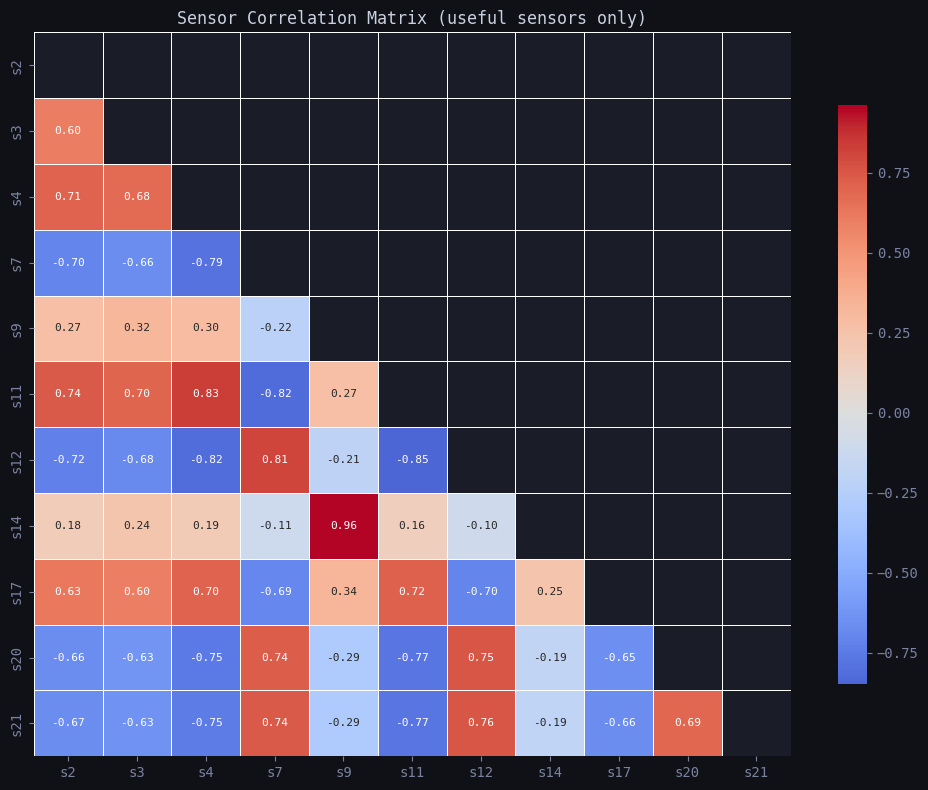

In [7]:
# ── 2d. Correlation heatmap of useful sensors ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = train[KEEP_SENSORS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
ax.set_title('Sensor Correlation Matrix (useful sensors only)')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Drop useless sensors ──────────────────────────────────────────────────────
DROP = ['s1','s5','s6','s8','s10','s13','s15','s16','s18','s19','os3']
train.drop(columns=DROP, inplace=True)
test.drop(columns=DROP,  inplace=True)

In [9]:
# ── Compute RUL labels ────────────────────────────────────────────────────────
RUL_CLIP = 125
 
def add_rul(df):
    max_cycle = df.groupby('unit')['cycle'].transform('max')
    df['RUL'] = (max_cycle - df['cycle']).clip(upper=RUL_CLIP)
    return df
 
train = add_rul(train)
 
last_cycles       = test.groupby('unit')['cycle'].max().reset_index()
last_cycles['RUL'] = rul['rul'].values
test = test.merge(last_cycles[['unit','RUL']], on='unit', how='left')
test_last = test.groupby('unit').last().reset_index()

In [10]:
# ── Global MinMax normalization (FD001 = single condition, no clustering) ─────
train[KEEP_SENSORS] = train[KEEP_SENSORS].astype(float)
test[KEEP_SENSORS]  = test[KEEP_SENSORS].astype(float)
 
scaler = MinMaxScaler()
train[KEEP_SENSORS] = scaler.fit_transform(train[KEEP_SENSORS])
test[KEEP_SENSORS]  = scaler.transform(test[KEEP_SENSORS])
 
print("Preprocessing complete.")
print(f"Train sensors: {train[KEEP_SENSORS].min().min():.3f} – {train[KEEP_SENSORS].max().max():.3f}")
print(f"Test  sensors: {test[KEEP_SENSORS].min().min():.3f}  – {test[KEEP_SENSORS].max().max():.3f}")
print(f"Train RUL: 0 – {train['RUL'].max()}")

Preprocessing complete.
Train sensors: 0.000 – 1.000
Test  sensors: -0.044  – 1.081
Train RUL: 0 – 125


In [11]:
# 4. SEQUENCE BUILDING
# ══════════════════════════════════════════════════════════════════════════════
WINDOW = 30   # FD001 engines are shorter (avg 206 cycles), 30 is sufficient
 
def build_sequences(df, feature_cols, window):
    X, y = [], []
    for _, eng in df.groupby('unit'):
        eng  = eng.sort_values('cycle')
        data = eng[feature_cols].values
        labs = eng['RUL'].values
        for i in range(len(data) - window + 1):
            X.append(data[i:i+window])
            y.append(labs[i+window-1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
 
def build_last_sequences(df, feature_cols, window):
    X, y = [], []
    for _, eng in df.groupby('unit'):
        eng  = eng.sort_values('cycle')
        data = eng[feature_cols].values
        if len(data) >= window:
            X.append(data[-window:])
        else:
            pad = np.zeros((window - len(data), len(feature_cols)))
            X.append(np.vstack([pad, data]))
        y.append(eng['RUL'].iloc[-1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [12]:
# ── Train / val split by engine (no leakage) ─────────────────────────────────
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, val_idx = next(gss.split(train, groups=train['unit']))
 
X_train, y_train_raw = build_sequences(train.iloc[tr_idx],  KEEP_SENSORS, WINDOW)
X_val,   y_val_raw   = build_sequences(train.iloc[val_idx], KEEP_SENSORS, WINDOW)
X_test,  y_test_raw  = build_last_sequences(test, KEEP_SENSORS, WINDOW)
 
# Normalize targets to [0, 1]
y_train = (y_train_raw / RUL_CLIP).astype(np.float32)
y_val   = (y_val_raw   / RUL_CLIP).astype(np.float32)
y_test_clipped = np.clip(y_test_raw, 0, RUL_CLIP).astype(np.float32)
 
print(f"\nSequence shapes:")
print(f"  X_train={X_train.shape}  y_train max={y_train_raw.max():.0f} (should be ≤{RUL_CLIP})")
print(f"  X_val  ={X_val.shape}")
print(f"  X_test ={X_test.shape}")


Sequence shapes:
  X_train=(14241, 30, 11)  y_train max=125 (should be ≤125)
  X_val  =(3490, 30, 11)
  X_test =(100, 30, 11)


In [13]:
def build_gru(window, n_features):
    inp = tf.keras.Input(shape=(window, n_features))
    x   = layers.GRU(128, return_sequences=True)(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.GRU(64, return_sequences=True)(x)
    x   = layers.Dropout(0.2)(x)
    x   = layers.GRU(32)(x)
    x   = layers.Dropout(0.15)(x)
    x   = layers.Dense(32, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dense(16, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inp, out)

In [14]:
model = build_gru(WINDOW, len(KEEP_SENSORS))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='mse',
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)
model.summary()

I0000 00:00:1777549000.552205      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 30, 128)        │        54,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,401 (400.00 KB)

 Trainable params: 102,401 (400.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ── Sample weights: give healthy engines more importance ──────────────────────
sample_weights = (1.0 + 1.5 * (y_train_raw / RUL_CLIP)).astype(np.float32)
 
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=256,
    sample_weight=sample_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150


I0000 00:00:1777549007.049152      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.2125 - rmse: 0.3391 - val_loss: 0.0621 - val_rmse: 0.2389 - learning_rate: 3.0000e-04
Epoch 2/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0950 - rmse: 0.2395 - val_loss: 0.0413 - val_rmse: 0.1907 - learning_rate: 3.0000e-04
Epoch 3/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0701 - rmse: 0.1951 - val_loss: 0.0279 - val_rmse: 0.1518 - learning_rate: 3.0000e-04
Epoch 4/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0562 - rmse: 0.1675 - val_loss: 0.0211 - val_rmse: 0.1276 - learning_rate: 3.0000e-04
Epoch 5/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0482 - rmse: 0.1511 - val_loss: 0.0211 - val_rmse: 0.1278 - learning_rate: 3.0000e-04
Epoch 6/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0404 - rmse: 0.1360 - val_loss: 0.0183 - val_rmse: 0.1169 - learning_rate: 3.0000e-04
Epoch 7/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0376 - rmse: 0.1305 - val_loss: 0.0177 - val_rmse: 0.1144 - le

In [17]:
def nasa_score(y_true, y_pred):
    d = y_pred.flatten() - y_true.flatten()
    return float(np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)))
 
val_preds  = model.predict(X_val).flatten()  * RUL_CLIP
test_preds = np.clip(model.predict(X_test).flatten() * RUL_CLIP, 0, RUL_CLIP)
 
rmse_val  = np.sqrt(mean_squared_error(y_val_raw,      val_preds))
rmse_test = np.sqrt(mean_squared_error(y_test_clipped, test_preds))
nasa      = nasa_score(y_test_clipped, test_preds)
 
print(f"\n{'='*40}")
print(f"  Val  RMSE : {rmse_val:.2f} cycles")
print(f"  Test RMSE : {rmse_test:.2f} cycles")
print(f"  NASA Score: {nasa:.1f}")
print(f"  Pred range: {test_preds.min():.1f} – {test_preds.max():.1f}")
print(f"  True range: {y_test_clipped.min():.1f} – {y_test_clipped.max():.1f}")
print(f"{'='*40}")

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

  Val  RMSE : 12.78 cycles
  Test RMSE : 14.69 cycles
  NASA Score: 409.0
  Pred range: 8.2 – 124.4
  True range: 7.0 – 125.0


In [18]:
results = pd.DataFrame({
    'unit':      test_last['unit'].values,
    'true_RUL':  y_test_clipped,
    'pred_RUL':  test_preds,
    'error':     test_preds - y_test_clipped,
    'abs_error': np.abs(test_preds - y_test_clipped)
})

In [19]:
bins   = [0, 30, 60, 90, 125]
labels = ['critical(0-30)', 'degrading(30-60)', 'mid(60-90)', 'healthy(90-125)']
results['bucket'] = pd.cut(results['true_RUL'], bins=bins, labels=labels)
bucket_stats = results.groupby('bucket', observed=True)['abs_error'].agg(['mean','count']).round(2)
print(f"\n=== Error by RUL bucket ===\n{bucket_stats}")
 
results['critical_true'] = results['true_RUL'] < 30
results['critical_pred'] = results['pred_RUL'] < 30
print(f"\n=== Critical zone (RUL < 30) ===")
print(confusion_matrix(results['critical_true'], results['critical_pred']))
print(classification_report(results['critical_true'], results['critical_pred'],
                             target_names=['safe', 'critical']))


=== Error by RUL bucket ===
                       mean  count
bucket                            
critical(0-30)     2.640000     25
degrading(30-60)   9.040000     14
mid(60-90)        25.450001     15
healthy(90-125)   10.310000     46

=== Critical zone (RUL < 30) ===
[[74  1]
 [ 2 23]]
              precision    recall  f1-score   support

        safe       0.97      0.99      0.98        75
    critical       0.96      0.92      0.94        25

    accuracy                           0.97       100
   macro avg       0.97      0.95      0.96       100
weighted avg       0.97      0.97      0.97       100



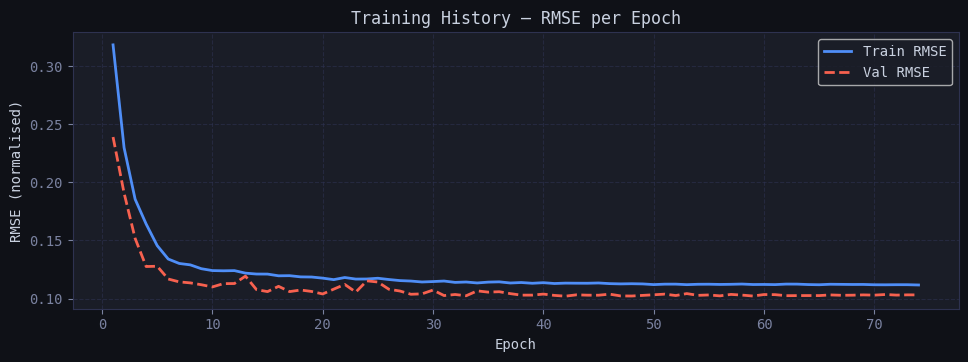

In [20]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0f1117')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
 
# ── 8a. Training history ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
epochs_ran = range(1, len(history.history['loss']) + 1)
ax1.plot(epochs_ran, history.history['rmse'],     color=ACCENT,  lw=2, label='Train RMSE')
ax1.plot(epochs_ran, history.history['val_rmse'], color=ACCENT2, lw=2, label='Val RMSE',  linestyle='--')
ax1.set_title('Training History — RMSE per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('RMSE (normalised)')
ax1.legend()
ax1.grid(True)

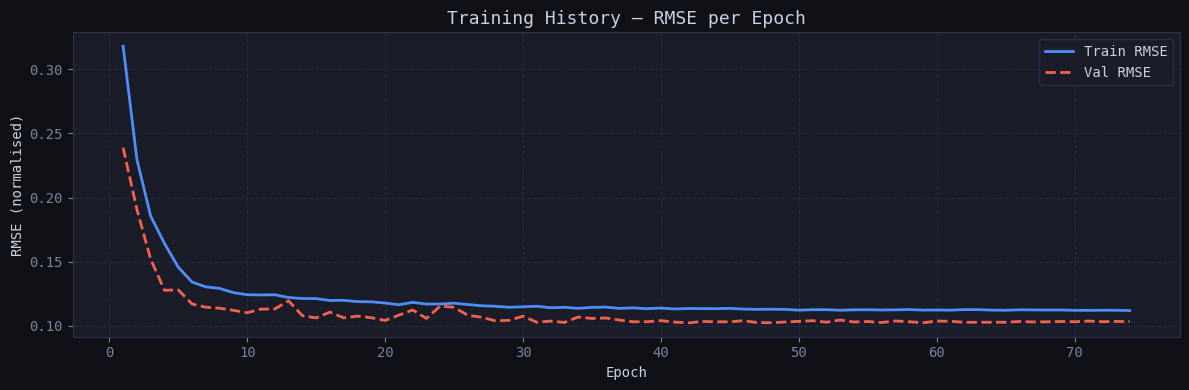

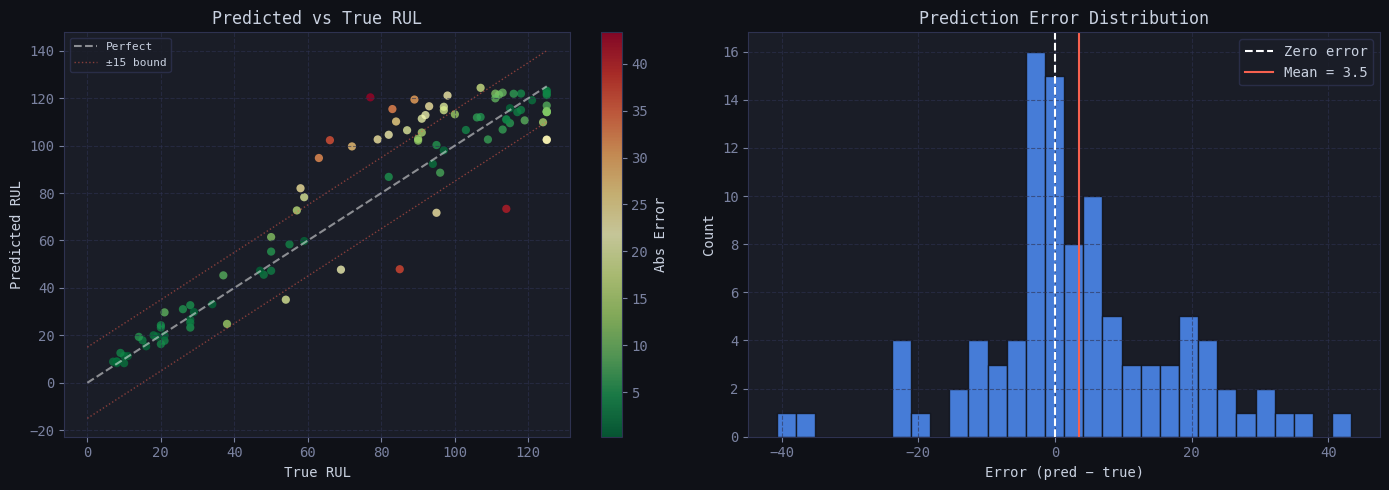

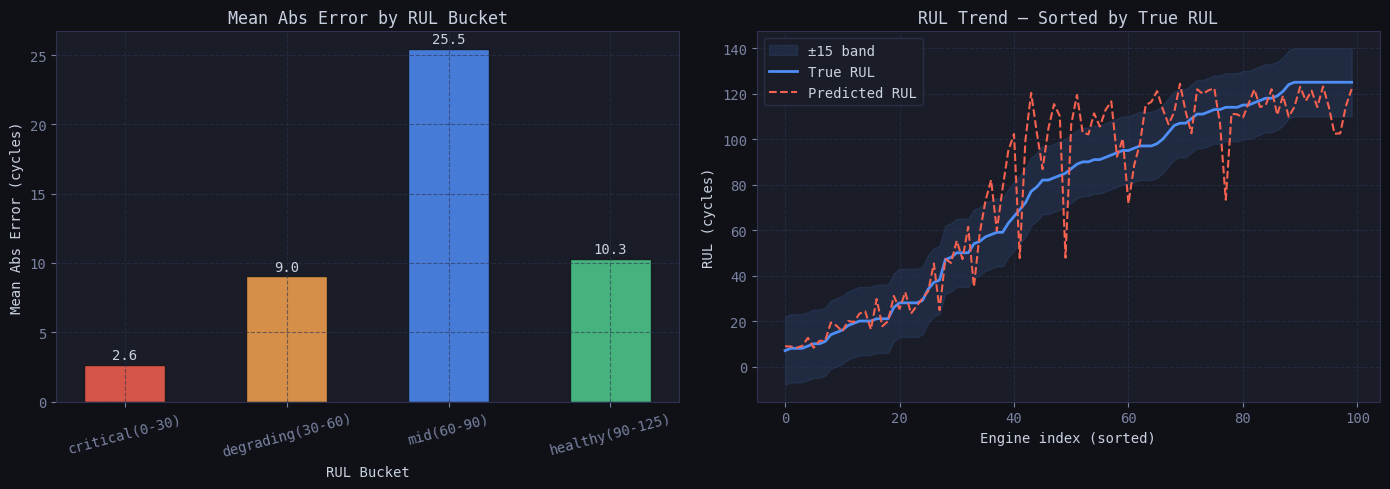

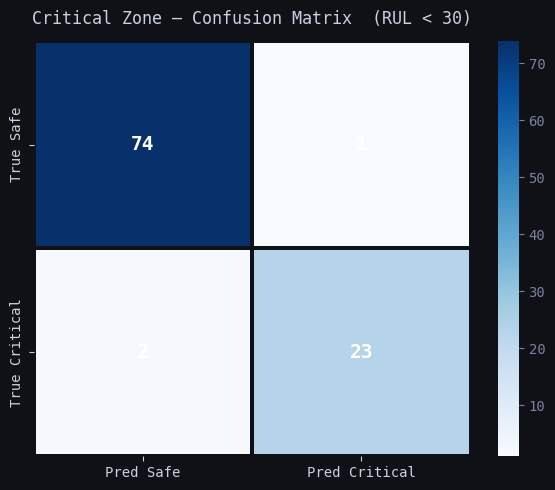


╔══════════════════════════════════╗
║        MODEL RESULTS             ║
╠══════════════════════════════════╣
║  Val  RMSE  :   12.78 cycles    ║
║  Test RMSE  :   14.69 cycles    ║
║  NASA Score :         409       ║
║  Window     :  30 cycles           ║
║  Features   :  11           ║
║  Dataset    :  FD001             ║
╚══════════════════════════════════╝



In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# 8. EVALUATION PLOTS — each figure separate for Kaggle compatibility
# ══════════════════════════════════════════════════════════════════════════════

DARK  = '#0f1117'
SURF  = '#1a1d27'
GRID  = '#2e3250'

def style_ax(ax):
    ax.set_facecolor(SURF)
    ax.tick_params(colors='#7a82a0')
    ax.xaxis.label.set_color('#c9d1e0')
    ax.yaxis.label.set_color('#c9d1e0')
    ax.title.set_color('#c9d1e0')
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.grid(True, color=GRID, linestyle='--', alpha=0.6)

# ── Plot 1: Training history ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4), facecolor=DARK)
style_ax(ax)
epochs_ran = range(1, len(history.history['loss']) + 1)
ax.plot(epochs_ran, history.history['rmse'],     color=ACCENT,  lw=2, label='Train RMSE')
ax.plot(epochs_ran, history.history['val_rmse'], color=ACCENT2, lw=2, label='Val RMSE', linestyle='--')
ax.set_title('Training History — RMSE per Epoch', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE (normalised)')
ax.legend(facecolor=SURF, edgecolor=GRID, labelcolor='#c9d1e0')
plt.tight_layout()
plt.show()

# ── Plot 2: Predicted vs True + Error distribution ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
style_ax(ax1); style_ax(ax2)

sc = ax1.scatter(results['true_RUL'], results['pred_RUL'],
                 c=results['abs_error'], cmap='RdYlGn_r',
                 alpha=0.75, s=35, edgecolors='none')
ax1.plot([0,125],[0,125],   color='white',  lw=1.5, linestyle='--', alpha=0.5, label='Perfect')
ax1.plot([0,125],[15,140],  color=ACCENT2,  lw=1,   linestyle=':',  alpha=0.5, label='±15 bound')
ax1.plot([0,125],[-15,110], color=ACCENT2,  lw=1,   linestyle=':',  alpha=0.5)
cbar = plt.colorbar(sc, ax=ax1)
cbar.ax.yaxis.set_tick_params(color='#7a82a0')
cbar.set_label('Abs Error', color='#c9d1e0')
ax1.set_title('Predicted vs True RUL', fontsize=12)
ax1.set_xlabel('True RUL');  ax1.set_ylabel('Predicted RUL')
ax1.legend(facecolor=SURF, edgecolor=GRID, labelcolor='#c9d1e0', fontsize=8)

ax2.hist(results['error'], bins=30, color=ACCENT, alpha=0.85, edgecolor=DARK)
ax2.axvline(0, color='white', lw=1.5, linestyle='--', label='Zero error')
ax2.axvline(results['error'].mean(), color=ACCENT2, lw=1.5,
            label=f'Mean = {results["error"].mean():.1f}')
ax2.set_title('Prediction Error Distribution', fontsize=12)
ax2.set_xlabel('Error (pred − true)');  ax2.set_ylabel('Count')
ax2.legend(facecolor=SURF, edgecolor=GRID, labelcolor='#c9d1e0')
plt.tight_layout()
plt.show()

# ── Plot 3: Error by bucket + RUL trend ───────────────────────────────────────
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
style_ax(ax3); style_ax(ax4)

bucket_colors = [ACCENT2, '#f7a44f', ACCENT, ACCENT3]
bars = ax3.bar(bucket_stats.index.astype(str), bucket_stats['mean'],
               color=bucket_colors, alpha=0.85, edgecolor=DARK, width=0.5)
for bar, val in zip(bars, bucket_stats['mean']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10, color='#c9d1e0')
ax3.set_title('Mean Abs Error by RUL Bucket', fontsize=12)
ax3.set_xlabel('RUL Bucket');  ax3.set_ylabel('Mean Abs Error (cycles)')
ax3.tick_params(axis='x', rotation=15)

sorted_df = results.sort_values('true_RUL').reset_index(drop=True)
ax4.fill_between(sorted_df.index,
                 sorted_df['true_RUL'] - 15, sorted_df['true_RUL'] + 15,
                 alpha=0.12, color=ACCENT, label='±15 band')
ax4.plot(sorted_df['true_RUL'], color=ACCENT,  lw=2,   label='True RUL')
ax4.plot(sorted_df['pred_RUL'], color=ACCENT2, lw=1.5, label='Predicted RUL', linestyle='--')
ax4.set_title('RUL Trend — Sorted by True RUL', fontsize=12)
ax4.set_xlabel('Engine index (sorted)');  ax4.set_ylabel('RUL (cycles)')
ax4.legend(facecolor=SURF, edgecolor=GRID, labelcolor='#c9d1e0')
plt.tight_layout()
plt.show()

# ── Plot 4: Confusion matrix ───────────────────────────────────────────────────
fig, ax5 = plt.subplots(figsize=(6, 5), facecolor=DARK)
ax5.set_facecolor(SURF)
cm = confusion_matrix(results['critical_true'], results['critical_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5,
            xticklabels=['Pred Safe', 'Pred Critical'],
            yticklabels=['True Safe', 'True Critical'],
            linewidths=1.5, linecolor=DARK,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'})
ax5.set_title('Critical Zone — Confusion Matrix  (RUL < 30)',
              fontsize=12, color='#c9d1e0', pad=12)
ax5.tick_params(colors='#c9d1e0')
plt.tight_layout()
plt.show()

# ── Metrics summary printout ───────────────────────────────────────────────────
print(f"""
╔══════════════════════════════════╗
║        MODEL RESULTS             ║
╠══════════════════════════════════╣
║  Val  RMSE  :  {rmse_val:6.2f} cycles    ║
║  Test RMSE  :  {rmse_test:6.2f} cycles    ║
║  NASA Score :  {nasa:10.0f}       ║
║  Window     :  {WINDOW} cycles           ║
║  Features   :  {len(KEEP_SENSORS)}           ║
║  Dataset    :  FD001             ║
╚══════════════════════════════════╝
""")

In [22]:
import pickle, json
 
model.save('gru_fd001.keras')
 
with open('scaler_fd001.pkl', 'wb') as f:
    pickle.dump(scaler, f)
 
config = {
    'window':      WINDOW,
    'rul_clip':    RUL_CLIP,
    'features':    KEEP_SENSORS,
    'n_features':  len(KEEP_SENSORS),
    'dataset':     'FD001',
    'model_file':  'gru_fd001.keras',
    'scaler_file': 'scaler_fd001.pkl'
}
with open('inference_config.json', 'w') as f:
    json.dump(config, f, indent=2)
 
print("\nArtifacts saved:")
print("  gru_fd001.keras       ← model")
print("  scaler_fd001.pkl      ← MinMaxScaler")
print("  inference_config.json ← window, features, rul_clip")
print("\nReady for real-time inference pipeline.")


Artifacts saved:
  gru_fd001.keras       ← model
  scaler_fd001.pkl      ← MinMaxScaler
  inference_config.json ← window, features, rul_clip

Ready for real-time inference pipeline.
